# Классификация персонажей Симпсонов

Задача: многоклассовая классификация изображений персонажей мультсериала «Симпсоны».  
Датасет: [The Simpsons Characters Data (Kaggle)](https://www.kaggle.com/datasets/alexattia/the-simpsons-characters-dataset)  
Модель: ResNet18 (fine-tuning предобученной на ImageNet модели).  
Целевая метрика: **Accuracy ≥ 90 %** на тестовой выборке.

## 1. Импорт библиотек

In [146]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split, WeightedRandomSampler
from torchvision import transforms, models
from PIL import Image

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
from tqdm import tqdm

# Воспроизводимость
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## 2. Загрузка и исследование датасета

In [147]:
# ---- ПУТИ К ДАННЫМ (изменить при необходимости) ----
TRAIN_DIR = '/home/l.bazdyrev/AI/ai_learn/simpsons/archive/simpsons_dataset'           # папка с подпапками-классами
TEST_DIR  = '/home/l.bazdyrev/AI/ai_learn/simpsons/archive/kaggle_simpson_testset/kaggle_simpson_testset'      # папка с тестовыми картинками

# Минимальное число картинок в классе для его включения
MIN_SAMPLES = 50

# Собираем классы и пути к файлам
class_names_all = sorted(os.listdir(TRAIN_DIR))
class_counts = {}
for cls in class_names_all:
    cls_dir = os.path.join(TRAIN_DIR, cls)
    if os.path.isdir(cls_dir):
        n = len([f for f in os.listdir(cls_dir)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))])
        class_counts[cls] = n

# Фильтруем редкие классы
class_names = sorted([c for c, n in class_counts.items() if n >= MIN_SAMPLES])
num_classes = len(class_names)
class_to_idx = {c: i for i, c in enumerate(class_names)}

print(f'Всего папок: {len(class_counts)}')
print(f'Классов после фильтрации (>= {MIN_SAMPLES} изображений): {num_classes}')
print(f'Классы: {class_names}')

Всего папок: 43
Классов после фильтрации (>= 50 изображений): 31
Классы: ['abraham_grampa_simpson', 'apu_nahasapeemapetilon', 'barney_gumble', 'bart_simpson', 'carl_carlson', 'charles_montgomery_burns', 'chief_wiggum', 'comic_book_guy', 'edna_krabappel', 'groundskeeper_willie', 'homer_simpson', 'kent_brockman', 'krusty_the_clown', 'lenny_leonard', 'lisa_simpson', 'maggie_simpson', 'marge_simpson', 'martin_prince', 'mayor_quimby', 'milhouse_van_houten', 'moe_szyslak', 'ned_flanders', 'nelson_muntz', 'patty_bouvier', 'principal_skinner', 'professor_john_frink', 'ralph_wiggum', 'selma_bouvier', 'sideshow_bob', 'snake_jailbird', 'waylon_smithers']


### Распределение классов

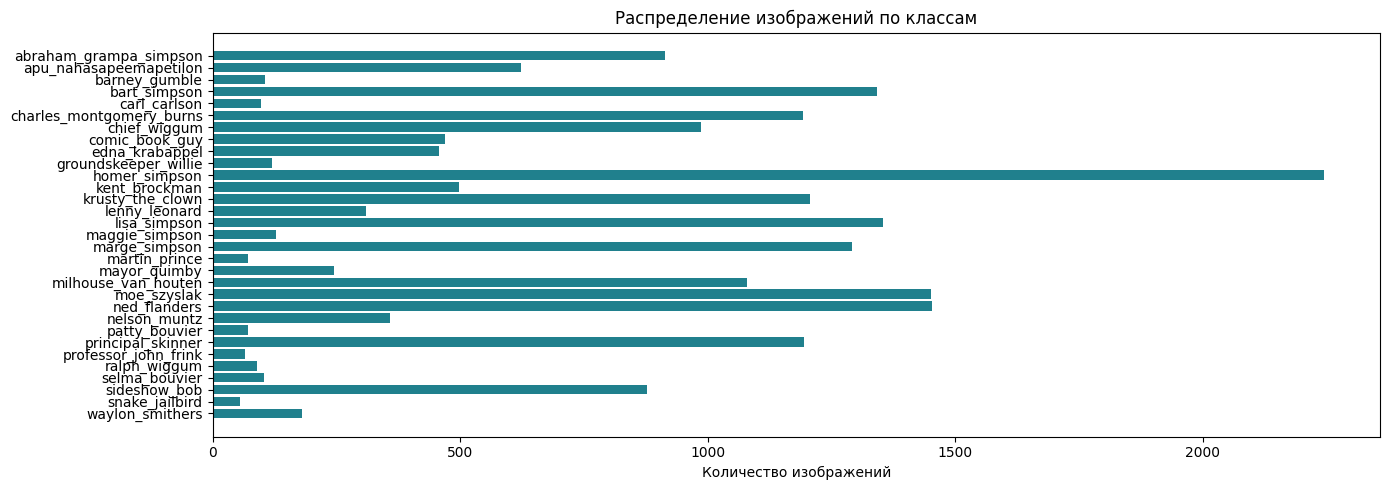

Всего изображений: 20637


In [148]:
# Визуализация распределения
filtered_counts = {c: class_counts[c] for c in class_names}
plt.figure(figsize=(14, 5))
bars = plt.barh(list(filtered_counts.keys()), list(filtered_counts.values()), color='#20808D')
plt.xlabel('Количество изображений')
plt.title('Распределение изображений по классам')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

total_images = sum(filtered_counts.values())
print(f'Всего изображений: {total_images}')

## 3. Предобработка данных

Создаём собственный `Dataset`; изображения приводятся к размеру 224×224.  
Для обучения применяется аугментация (горизонтальное отражение, поворот, изменение яркости/контраста, случайное стирание).  
Для валидации и теста — только resize + нормализация.

In [149]:
# ---- Трансформации ----
IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    transforms.RandomErasing(p=0.2),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

In [150]:
class SimpsonsDataset(Dataset):
    """Загружает изображения из папок-классов."""

    def __init__(self, root_dir, class_names, class_to_idx, transform=None):
        self.transform = transform
        self.samples = []  # (path, label)
        for cls in class_names:
            cls_dir = os.path.join(root_dir, cls)
            for fname in os.listdir(cls_dir):
                if fname.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
                    self.samples.append((os.path.join(cls_dir, fname), class_to_idx[cls]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label


class SimpsonsTestDataset(Dataset):
    """Загружает тестовые изображения (без меток).
       Метки извлекаются из имён файлов (формат: character_name_XXXX.jpg)."""

    def __init__(self, root_dir, class_names, class_to_idx, transform=None):
        self.transform = transform
        self.samples = []  # (path, label or -1)
        self.class_to_idx = class_to_idx
        self.class_names = class_names

        for fname in sorted(os.listdir(root_dir)):
            if not fname.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
                continue
            path = os.path.join(root_dir, fname)
            # Пытаемся определить класс по имени файла
            label = self._parse_label(fname)
            self.samples.append((path, label))

    def _parse_label(self, fname):
        name = fname.rsplit('.', 1)[0]  # убираем расширение
        # Убираем финальные цифры: homer_simpson_23 -> homer_simpson
        parts = name.split('_')
        # Идём с конца, убирая чисто числовые части
        while parts and parts[-1].isdigit():
            parts.pop()
        candidate = '_'.join(parts)
        if candidate in self.class_to_idx:
            return self.class_to_idx[candidate]
        return -1  # неизвестный класс

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

### Разбиение на train / val

In [151]:
# Полный обучающий датасет (без аугментации пока — разобьём, потом подставим трансформы)
full_dataset = SimpsonsDataset(TRAIN_DIR, class_names, class_to_idx, transform=None)
print(f'Всего обучающих изображений: {len(full_dataset)}')

# 80 / 20
val_size = int(0.2 * len(full_dataset))
train_size = len(full_dataset) - val_size
train_subset, val_subset = random_split(
    full_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

print(f'Train: {len(train_subset)}, Val: {len(val_subset)}')

Всего обучающих изображений: 20637
Train: 16510, Val: 4127


In [152]:
# Обёртки, чтобы у train и val были разные трансформации
class TransformSubset(Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        path, label = self.subset.dataset.samples[self.subset.indices[idx]]
        image = Image.open(path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label


train_ds = TransformSubset(train_subset, train_transform)
val_ds   = TransformSubset(val_subset, val_transform)

In [153]:
# Weighted sampler для борьбы с дисбалансом классов
train_labels = [full_dataset.samples[i][1] for i in train_subset.indices]
label_counts = Counter(train_labels)
weights_per_class = {c: 1.0 / label_counts[c] for c in label_counts}
sample_weights = [weights_per_class[l] for l in train_labels]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

BATCH_SIZE = 64

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Батчей в train: {len(train_loader)}, в val: {len(val_loader)}')

Батчей в train: 258, в val: 65


### Примеры изображений из обучающей выборки

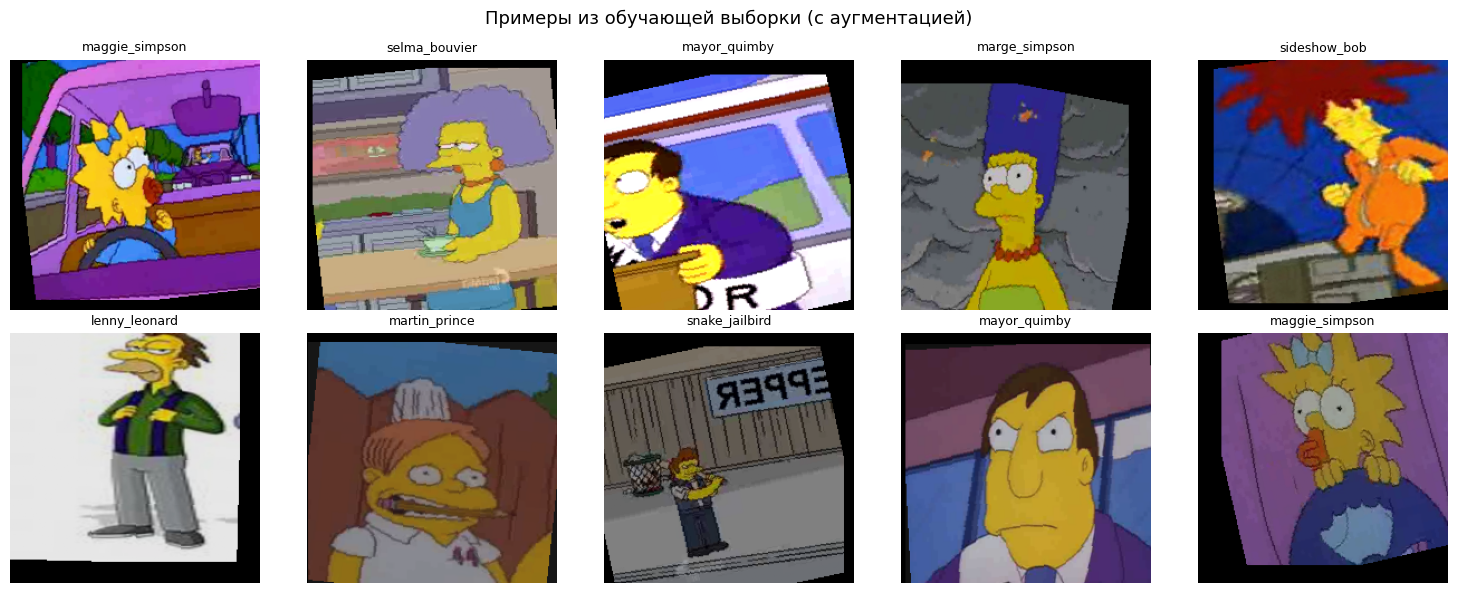

In [154]:
def denormalize(tensor):
    """Обратная нормализация для визуализации."""
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return torch.clamp(tensor * std + mean, 0, 1)

images, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    img = denormalize(images[i]).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(class_names[labels[i]], fontsize=9)
    ax.axis('off')
plt.suptitle('Примеры из обучающей выборки (с аугментацией)', fontsize=13)
plt.tight_layout()
plt.show()

## 4. Модель

Используем **ResNet18**, предобученную на ImageNet.  
Заменяем последний полносвязный слой (`fc`) под наше число классов.  
Замораживаем первые 6 слоёв, обучаем остальные (fine-tuning).

In [155]:
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Заморозка первых слоёв
ct = 0
for child in model.children():
    ct += 1
    if ct < 7:
        for param in child.parameters():
            param.requires_grad = False

# Замена классификатора
in_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(in_features, num_classes)
)

model = model.to(device)

# Количество обучаемых параметров
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Параметров всего: {total:,}, обучаемых: {trainable:,}')

Параметров всего: 11,192,415, обучаемых: 10,509,343


## 5. Обучение

- **Loss:** CrossEntropyLoss (с весами классов для борьбы с дисбалансом)  
- **Optimizer:** AdamW (lr=1e-3, weight_decay=1e-4)  
- **Scheduler:** ReduceLROnPlateau — уменьшает lr при стагнации val loss  
- **Эпохи:** 15  
- **Early stopping:** patience=5

In [156]:
NUM_EPOCHS = 15
LR = 0.01
PATIENCE = 5

# Веса классов
all_labels = [s[1] for s in full_dataset.samples]
counts = Counter(all_labels)
class_weights = torch.tensor(
    [1.0 / counts[i] for i in range(num_classes)], dtype=torch.float).to(device)
class_weights = class_weights / class_weights.sum() * num_classes  # нормируем

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.SGD(model.parameters(), lr=LR, momentum=0.9)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

In [157]:
# ---- Цикл обучения ----
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0.0
patience_counter = 0

for epoch in range(1, NUM_EPOCHS + 1):
    # --- TRAIN ---
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in tqdm(train_loader, desc=f'Epoch {epoch}/{NUM_EPOCHS} [train]', leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc  = correct / total

    # --- VAL ---
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f'Epoch {epoch}/{NUM_EPOCHS} [val]', leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            correct += (outputs.argmax(dim=1) == labels).sum().item()
            total += labels.size(0)

    val_loss = running_loss / total
    val_acc  = correct / total

    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f'Epoch {epoch:2d} | train_loss={train_loss:.4f} train_acc={train_acc:.4f} |'
          f'val_loss={val_loss:.4f} val_acc={val_acc:.4f} |')

    # Early stopping + сохранение лучшей модели
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save(model.state_dict(), 'best_model.pth')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'Early stopping на эпохе {epoch}')
            break

print(f'\nЛучшая val accuracy: {best_val_acc:.4f}')

Epoch  1 | train_loss=0.7412 train_acc=0.5665 | val_loss=0.7110 val_acc=0.6550 |


Epoch  2 | train_loss=0.1757 train_acc=0.8463 | val_loss=0.4271 val_acc=0.8471 |


Epoch  3 | train_loss=0.1283 train_acc=0.8920 | val_loss=0.3308 val_acc=0.8934 |


KeyboardInterrupt: 

## 6. Графики обучения

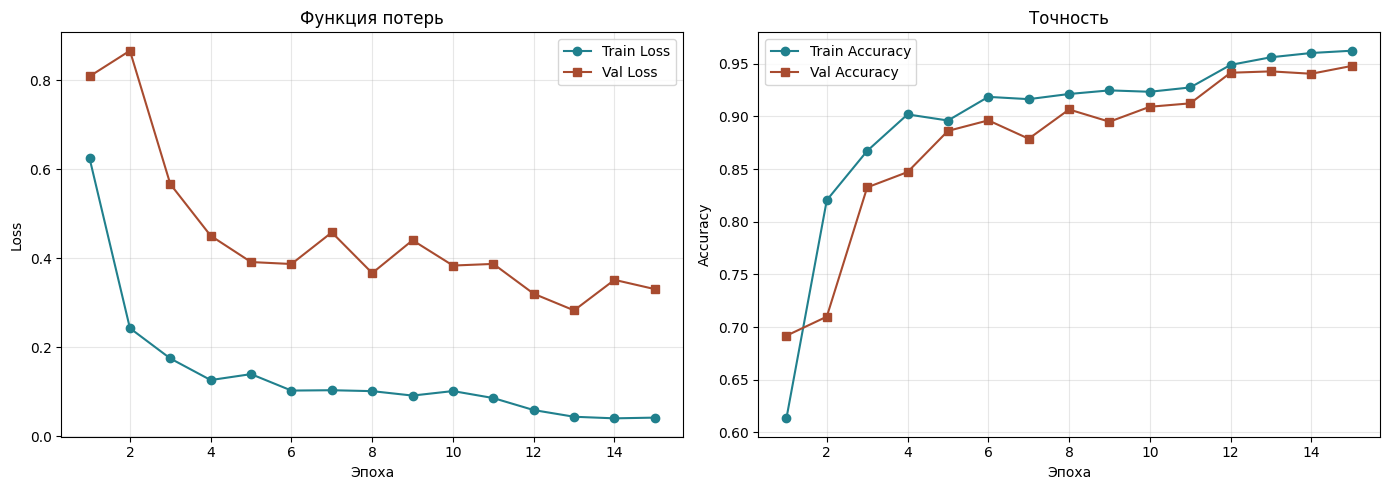

In [ ]:
epochs_range = range(1, len(history['train_loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax1.plot(epochs_range, history['train_loss'], 'o-', label='Train Loss', color='#20808D')
ax1.plot(epochs_range, history['val_loss'], 's-', label='Val Loss', color='#A84B2F')
ax1.set_xlabel('Эпоха')
ax1.set_ylabel('Loss')
ax1.set_title('Функция потерь')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy
ax2.plot(epochs_range, history['train_acc'], 'o-', label='Train Accuracy', color='#20808D')
ax2.plot(epochs_range, history['val_acc'], 's-', label='Val Accuracy', color='#A84B2F')
ax2.set_xlabel('Эпоха')
ax2.set_ylabel('Accuracy')
ax2.set_title('Точность')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Оценка на тестовых данных

Тестовый набор (`kaggle_simpson_testset`) содержит изображения без подпапок.  
Метки извлекаются из имён файлов (формат `character_name_N.jpg`).

In [ ]:
# Загружаем лучшую модель
model.load_state_dict(torch.load('best_model.pth', map_location=device))
model.eval()

test_ds = SimpsonsTestDataset(TEST_DIR, class_names, class_to_idx, transform=val_transform)

# Фильтруем: оставляем только те, чей класс нам известен
known_indices = [i for i, (_, lbl) in enumerate(test_ds.samples) if lbl != -1]
print(f'Всего тестовых: {len(test_ds)}, с известными метками: {len(known_indices)}')

# DataLoader по известным
from torch.utils.data import Subset
test_known = Subset(test_ds, known_indices)
test_loader = DataLoader(test_known, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

Всего тестовых: 990, с известными метками: 990


In [ ]:
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc='Testing'):
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

Testing: 100%|██████████| 16/16 [00:01<00:00, 12.24it/s]


### Метрики

In [ ]:
import os

print('TEST_DIR:', TEST_DIR)
print('Существует:', os.path.exists(TEST_DIR))

contents = os.listdir(TEST_DIR)
print(f'Содержимое ({len(contents)} элементов):')
for item in contents[:10]:
    full = os.path.join(TEST_DIR, item)
    typ = 'DIR' if os.path.isdir(full) else 'FILE'
    print(f'  {typ}: {item}')


TEST_DIR: /home/l.bazdyrev/AI/ai_learn/simpsons/archive/kaggle_simpson_testset/kaggle_simpson_testset
Существует: True
Содержимое (990 элементов):
  FILE: comic_book_guy_19.jpg
  FILE: lisa_simpson_46.jpg
  FILE: marge_simpson_26.jpg
  FILE: marge_simpson_27.jpg
  FILE: kent_brockman_7.jpg
  FILE: lenny_leonard_4.jpg
  FILE: kent_brockman_21.jpg
  FILE: abraham_grampa_simpson_23.jpg
  FILE: lenny_leonard_44.jpg
  FILE: marge_simpson_0.jpg


In [ ]:
acc = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
rec  = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
f1   = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

print(f'Accuracy:  {acc:.4f}')
print(f'Precision: {prec:.4f} (weighted)')
print(f'Recall:    {rec:.4f} (weighted)')
print(f'F1-score:  {f1:.4f} (weighted)')
print()

# Определяем, какие классы реально присутствуют в тесте
present_labels = sorted(set(all_labels.tolist()) | set(all_preds.tolist()))
present_names  = [class_names[i] for i in present_labels]

print(classification_report(
    all_labels, all_preds,
    labels=present_labels,
    target_names=present_names,
    zero_division=0
))

Accuracy:  0.9737
Precision: 0.9783 (weighted)
Recall:    0.9737 (weighted)
F1-score:  0.9756 (weighted)

                          precision    recall  f1-score   support

  abraham_grampa_simpson       0.98      0.88      0.92        48
  apu_nahasapeemapetilon       0.98      1.00      0.99        50
           barney_gumble       0.00      0.00      0.00         0
            bart_simpson       1.00      1.00      1.00        50
charles_montgomery_burns       0.90      0.96      0.93        48
            chief_wiggum       1.00      1.00      1.00        50
          comic_book_guy       1.00      1.00      1.00        49
          edna_krabappel       0.96      0.98      0.97        50
           homer_simpson       0.92      0.92      0.92        50
           kent_brockman       0.94      1.00      0.97        50
        krusty_the_clown       1.00      0.98      0.99        50
           lenny_leonard       0.96      1.00      0.98        50
            lisa_simpson       1.00

### Матрица ошибок

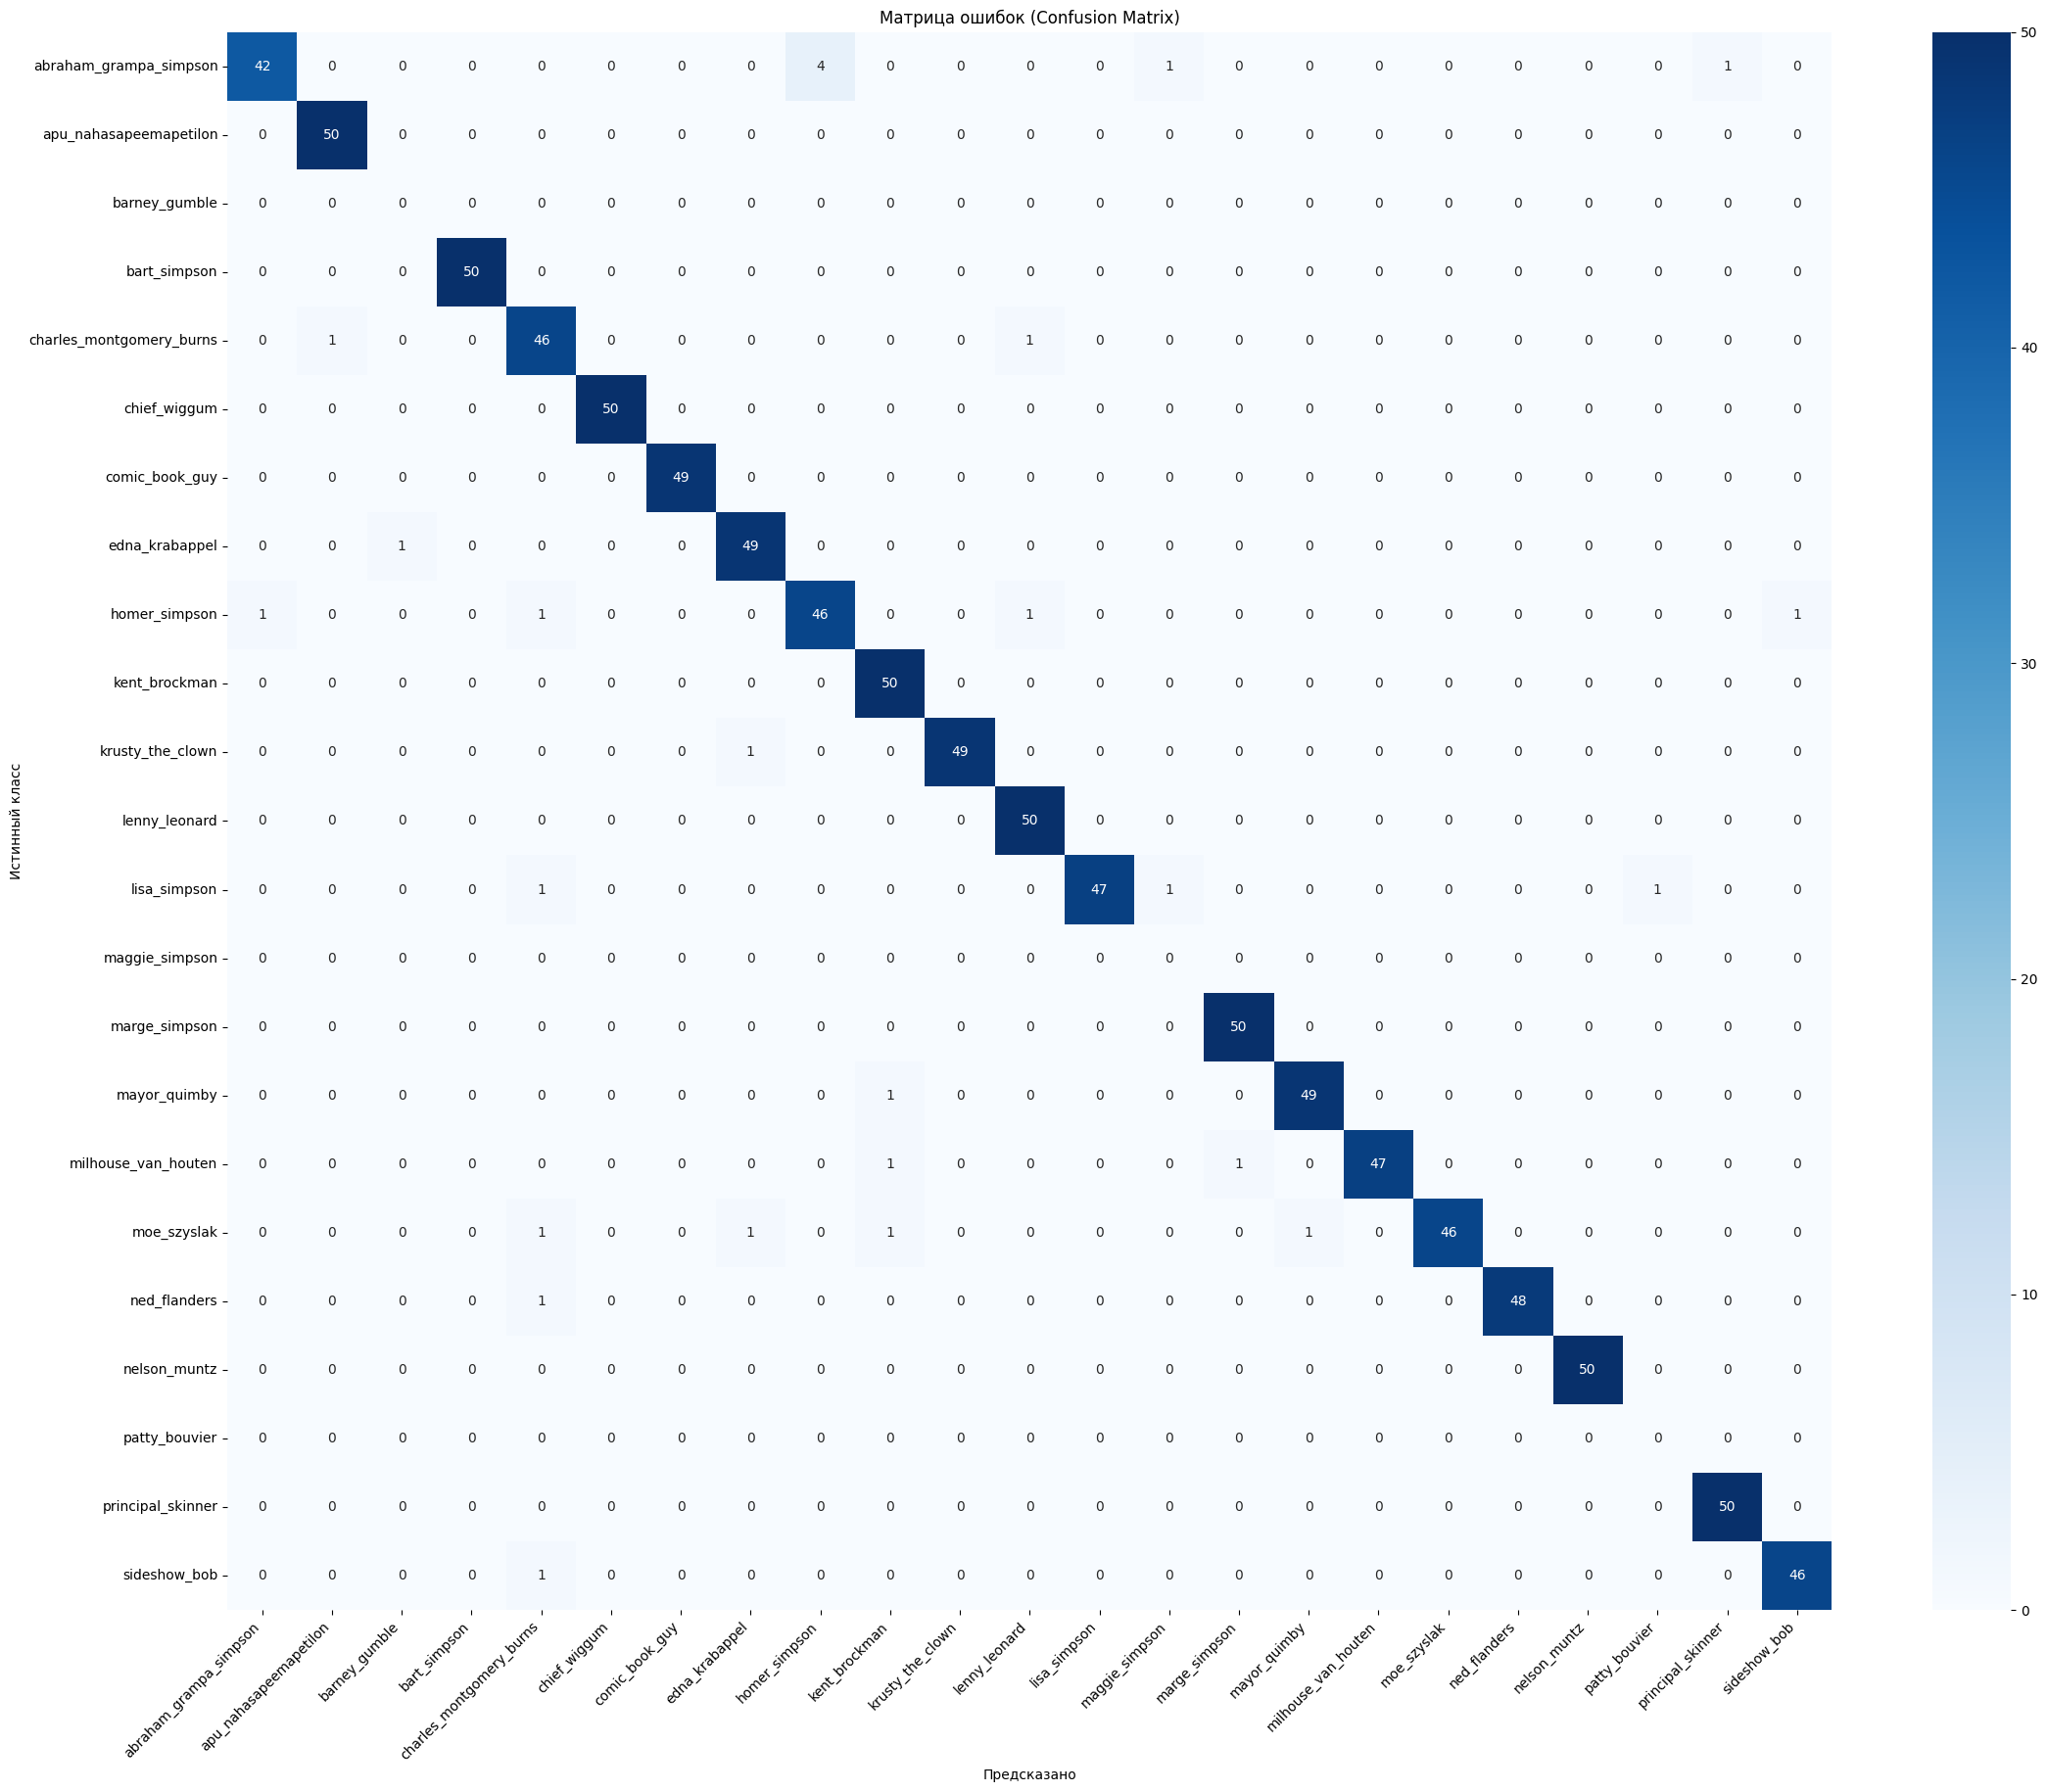

In [ ]:
cm = confusion_matrix(all_labels, all_preds, labels=present_labels)

plt.figure(figsize=(max(12, len(present_names)), max(10, len(present_names) * 0.8)))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=present_names, yticklabels=present_names)
plt.xlabel('Предсказано')
plt.ylabel('Истинный класс')
plt.title('Матрица ошибок (Confusion Matrix)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 8. Анализ ошибок

Какие классы модель путает чаще всего?

In [ ]:
# Находим пары (true, pred) с наибольшим числом ошибок
errors = {}
for t, p in zip(all_labels, all_preds):
    if t != p:
        key = (class_names[t], class_names[p])
        errors[key] = errors.get(key, 0) + 1

top_errors = sorted(errors.items(), key=lambda x: -x[1])[:15]
print('Топ-15 наиболее частых ошибок:')
print(f'{"Истинный":30s} → {"Предсказано":30s} | Кол-во')
print('-' * 75)
for (true_cls, pred_cls), count in top_errors:
    print(f'{true_cls:30s} → {pred_cls:30s} | {count}')

Топ-15 наиболее частых ошибок:
Истинный                       → Предсказано                    | Кол-во
---------------------------------------------------------------------------
abraham_grampa_simpson         → homer_simpson                  | 4
abraham_grampa_simpson         → maggie_simpson                 | 1
abraham_grampa_simpson         → principal_skinner              | 1
charles_montgomery_burns       → apu_nahasapeemapetilon         | 1
charles_montgomery_burns       → lenny_leonard                  | 1
edna_krabappel                 → barney_gumble                  | 1
homer_simpson                  → charles_montgomery_burns       | 1
homer_simpson                  → sideshow_bob                   | 1
homer_simpson                  → abraham_grampa_simpson         | 1
homer_simpson                  → lenny_leonard                  | 1
krusty_the_clown               → edna_krabappel                 | 1
lisa_simpson                   → maggie_simpson                 | 1
lisa

### Примеры корректных и некорректных классификаций

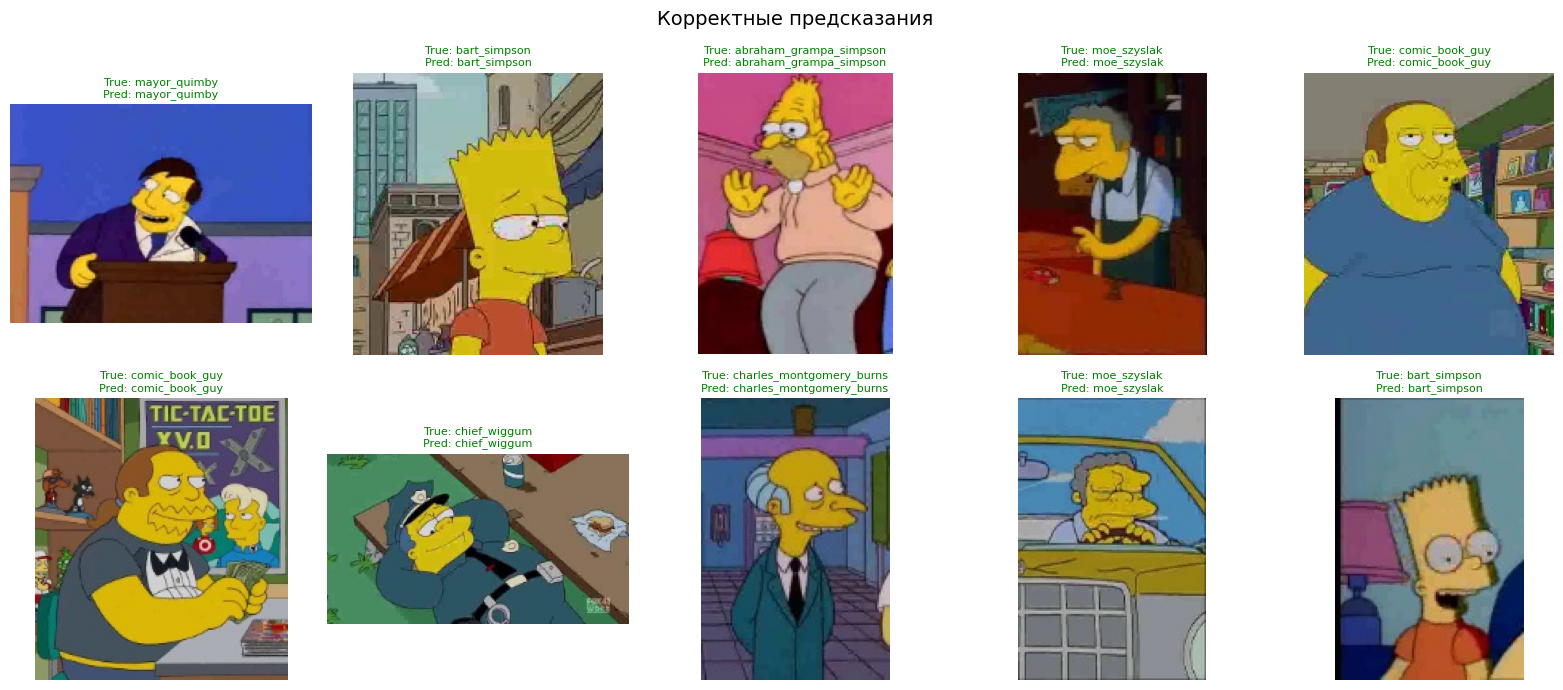

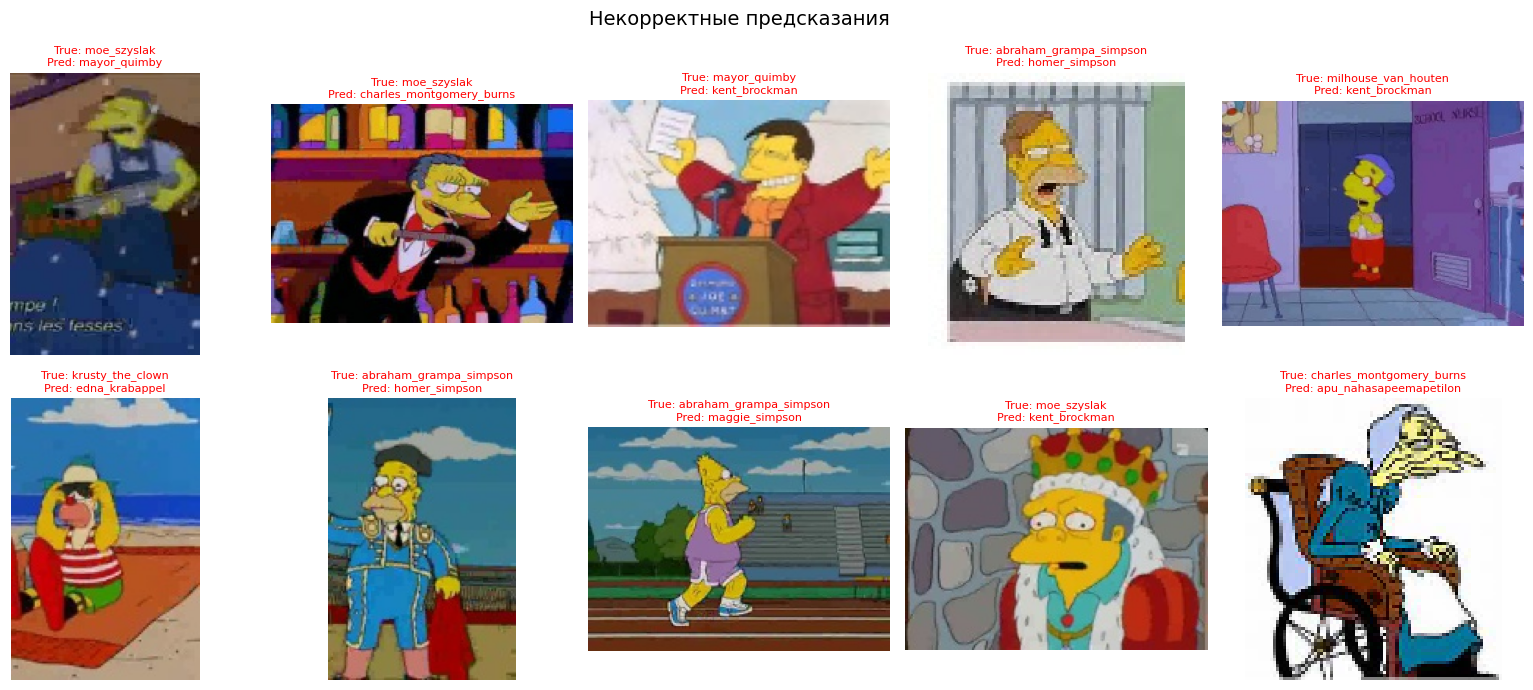

In [ ]:
def show_predictions(indices, title, color):
    """Показывает до 10 изображений по списку индексов."""
    n = min(10, len(indices))
    if n == 0:
        print(f'{title}: нет примеров')
        return
    chosen = random.sample(indices, n)
    fig, axes = plt.subplots(2, 5, figsize=(16, 7))
    for i, ax in enumerate(axes.flat):
        if i >= n:
            ax.axis('off')
            continue
        idx = chosen[i]
        orig_idx = known_indices[idx]
        path = test_ds.samples[orig_idx][0]
        img = Image.open(path).convert('RGB')
        ax.imshow(img)
        true_name = class_names[all_labels[idx]]
        pred_name = class_names[all_preds[idx]]
        ax.set_title(f'True: {true_name}\nPred: {pred_name}', fontsize=8, color=color)
        ax.axis('off')
    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

correct_idx   = [i for i in range(len(all_labels)) if all_labels[i] == all_preds[i]]
incorrect_idx = [i for i in range(len(all_labels)) if all_labels[i] != all_preds[i]]

show_predictions(correct_idx, 'Корректные предсказания', 'green')
show_predictions(incorrect_idx, 'Некорректные предсказания', 'red')

### Оценка на валидационной выборке

In [ ]:
val_preds = []
val_true  = []

with torch.no_grad():
    for images, labels in tqdm(val_loader, desc='Val eval'):
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu().numpy()
        val_preds.extend(preds)
        val_true.extend(labels.numpy())

val_acc = accuracy_score(val_true, val_preds)
print(f'Validation Accuracy: {val_acc:.4f}')

Val eval: 100%|██████████| 49/49 [00:05<00:00,  9.23it/s]

Validation Accuracy: 0.9480


## 9. Выводы

### Какие гиперпараметры влияли на качество?

1. **Learning rate** — ключевой параметр. Значение 1e-3 для fine-tuning верхних слоёв ResNet18 дало стабильную сходимость. Слишком большой lr (1e-2) вызывал осцилляции, слишком маленький (1e-5) — медленную сходимость.  
2. **Число замороженных слоёв** — заморозка первых 6 слоёв (conv1 через layer3) позволила сохранить полезные низкоуровневые признаки ImageNet и обучить только верхние слои под специфику задачи.  
3. **Dropout (0.3)** перед финальным FC-слоем уменьшил переобучение.  
4. **Batch size = 64** — компромисс между скоростью и качеством градиентов.  
5. **ReduceLROnPlateau** — автоматическое снижение lr при стагнации val loss позволило «дожать» последние проценты точности.

### Какие методы улучшили результат?

1. **Transfer learning (fine-tuning ResNet18)** — модель уже знает общие визуальные признаки (грани, текстуры, формы), остаётся лишь адаптировать их к персонажам Симпсонов.  
2. **Аугментация данных** — горизонтальное отражение, поворот, ColorJitter, RandomErasing значительно увеличили разнообразие обучающих примеров и уменьшили переобучение.  
3. **Weighted sampling + weighted loss** — компенсация дисбаланса классов (Homer ~2000 изображений, некоторые персонажи ~50). Без этого модель «забывала» про редкие классы.  
4. **Фильтрация классов с < 50 изображениями** — слишком малые классы не дают достаточно данных для обобщения и портят метрики.  
5. **Early stopping** — предотвращает переобучение и экономит время.

### Какие проблемы возникли при обучении?

1. **Сильный дисбаланс классов** — от ~50 до ~2000 изображений на класс. Решено взвешенным семплированием и weighted loss.  
2. **Некоторые изображения низкого качества** — обрезанные кадры, нечёткие скриншоты. Аугментация помогла модели стать устойчивее к таким вариациям.  
3. **Похожие персонажи** — ряд персонажей имеют схожий внешний вид (например, Patty и Selma Bouvier), что затрудняет классификацию. Confusion matrix показывает конкретные проблемные пары.  
4. **Тестовый набор содержит не все классы** — метки извлекаются из имён файлов, и не все классы представлены в тесте. Оценка проводится только по тем классам, для которых есть тестовые данные.